# 🏁 Carrera de robots 🤖: ¿qué tan lejos puede correr tu agente?

En esta actividad entrenarás a un robot bípedo virtual (**BipedalWalker** de Gymnasium) con el algoritmo **REINFORCE con baseline**. El robot empieza sin saber caminar, así que al principio sus movimientos serán torpes y, con suerte, divertidos. Al final del entrenamiento se medirá **la distancia que logra recorrer**.

**Tu objetivo:** elegir los hiperparámetros que consigan que el robot llegue lo más lejos posible.

## Reglas
1. Solo puedes modificar los valores de la celda **"2. Configuración"**. No cambies el resto del código.
2. Cada valor debe estar dentro del rango permitido (tabla de abajo). Si alguno queda fuera, el cuaderno lo avisará y no entrenará.
3. Usa un entorno de ejecución **CPU** (no necesitas GPU).
4. Ejecuta las celdas **en orden**, de arriba hacia abajo.
5. Al terminar, reporta el resultado que aparece en la última celda (**"Resultado para reportar"**).

## Hiperparámetros

| Parámetro | Qué controla | Rango permitido | Valor inicial |
|---|---|---|---|
| `N_ITERS` | Número de actualizaciones de la política (más iteraciones = más entrenamiento y más tiempo) | entero `[50 a 600]` | 400 |
| `BATCH_STEPS` | Pasos de simulación recogidos en cada iteración (más pasos = gradiente menos ruidoso, pero más lento) | entero `[1000 a 20000]` | 5000 |
| `LR_POLICY` | Tasa de aprendizaje de la política | `[0.00001 a 0.01]` | 0.0003 |
| `LR_VALUE` | Tasa de aprendizaje del baseline (red de valor) | `[0.00001 a 0.01]` | 0.001 |
| `GAMMA` | Factor de descuento de las recompensas futuras | `[0.9 a 0.999]` | 0.99 |
| `ENT_COEF` | Peso del bono de entropía (favorece la exploración) | `[0.0 a 0.05]` | 0.0 |
| `HIDDEN` | Neuronas por capa oculta de las redes | entero `[16 a 512]` | 128 |
| `SEED` | Semilla aleatoria (cambiarla da un entrenamiento distinto) | entero `>= 0` | 0 |
| `VIDEO_EVERY` | Cada cuántas iteraciones se graba un video (no afecta el aprendizaje) | entero `[10 a 100]` | 25 |
| `VIDEO_STEPS` | Pasos máximos de cada video durante el entrenamiento (no afecta el aprendizaje) | entero `[100 a 1600]` | 500 |

## Cómo se mide la distancia
Al terminar el entrenamiento, el agente corre **20 episodios** en terrenos fijos (los mismos para todos los estudiantes), usando su política sin ruido aleatorio. En cada episodio se mide cuánto avanzó el torso del robot hacia adelante desde la posición inicial. La distancia está en **unidades del simulador** y la meta del circuito está a **84 unidades**. Como referencia, un robot que no hace nada avanza unas 2 unidades (se cae hacia adelante), y uno que mueve las patas al azar avanza menos de 1. El valor que se reporta es el **promedio de los 20 episodios**.

## 1. Instalación

In [ ]:
!apt-get -qq update
!apt-get -qq install -y swig | tail -n 2
!pip -q install "gymnasium[box2d]" imageio imageio-ffmpeg

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu noble InRelease' does not seem to provide it (sources.list entry misspelt?)
Setting up swig (4.2.0-2ubuntu1) ...
Processing triggers for man-db (2.12.0-4build2) ...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 64.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 50.6 MB/s eta 0:00:00


## 2. Configuración (aquí eliges tus hiperparámetros)

In [ ]:
#@title Configuración { display-mode: "form" }
#@markdown ### Datos del estudiante
NOMBRE_ESTUDIANTE = "" #@param {type:"string"}

#@markdown ### Hiperparámetros (respeta los rangos indicados)
#@markdown **N_ITERS**: iteraciones de entrenamiento · rango: entero [50 a 600]
N_ITERS      = 400   #@param {type:"integer"}
#@markdown **BATCH_STEPS**: pasos de simulación por iteración · rango: entero [1000 a 20000]
BATCH_STEPS  = 5000  #@param {type:"integer"}
#@markdown **LR_POLICY**: tasa de aprendizaje de la política · rango: [0.00001 a 0.01]
LR_POLICY    = 3e-4  #@param {type:"number"}
#@markdown **LR_VALUE**: tasa de aprendizaje del baseline · rango: [0.00001 a 0.01]
LR_VALUE     = 1e-3  #@param {type:"number"}
#@markdown **GAMMA**: factor de descuento · rango: [0.9 a 0.999]
GAMMA        = 0.99  #@param {type:"number"}
#@markdown **ENT_COEF**: bono de entropía · rango: [0.0 a 0.05]
ENT_COEF     = 0.0   #@param {type:"number"}
#@markdown **HIDDEN**: neuronas por capa oculta · rango: entero [16 a 512]
HIDDEN       = 128   #@param {type:"integer"}
#@markdown **SEED**: semilla aleatoria · rango: entero >= 0
SEED         = 0     #@param {type:"integer"}

#@markdown ### Videos (no afectan el aprendizaje)
#@markdown **VIDEO_EVERY**: cada cuántas iteraciones se graba un video · rango: entero [10 a 100]
VIDEO_EVERY  = 25    #@param {type:"integer"}
#@markdown **VIDEO_STEPS**: pasos máximos por video · rango: entero [100 a 1600]
VIDEO_STEPS  = 500   #@param {type:"integer"}

## 3. Código del algoritmo y de la medición (no modificar)

In [ ]:
import os
import sys
import time, base64
import numpy as np
import torch, torch.nn as nn, torch.nn.functional as F
import gymnasium as gym
import imageio
import matplotlib.pyplot as plt
from IPython.display import HTML, display

torch.set_num_threads(2)
os.makedirs("videos", exist_ok=True)
MIN_LOG_STD = -2.0


class RunningNorm:
    # Normaliza observaciones con media/varianza móviles (ayuda MUCHO a REINFORCE).
    def __init__(self, dim):
        self.mean = np.zeros(dim); self.var = np.ones(dim); self.count = 1e-4
    def update(self, x):
        bm, bv, bc = x.mean(0), x.var(0), x.shape[0]
        d = bm - self.mean; tot = self.count + bc
        self.mean = self.mean + d * bc / tot
        self.var = (self.var * self.count + bv * bc + d**2 * self.count * bc / tot) / tot
        self.count = tot
    def __call__(self, x):
        return np.clip((x - self.mean) / np.sqrt(self.var + 1e-8), -10, 10).astype(np.float32)


class Agent(nn.Module):
    def __init__(self, obs_dim, act_dim, hidden=128, init_log_std=-0.5):
        super().__init__()
        self.mu = nn.Sequential(nn.Linear(obs_dim, hidden), nn.Tanh(),
                                nn.Linear(hidden, hidden), nn.Tanh(),
                                nn.Linear(hidden, act_dim))
        self.v = nn.Sequential(nn.Linear(obs_dim, hidden), nn.Tanh(),
                               nn.Linear(hidden, hidden), nn.Tanh(),
                               nn.Linear(hidden, 1))
        self.log_std = nn.Parameter(torch.full((act_dim,), float(init_log_std)))
        with torch.no_grad():               # empieza casi quieto: la exploración viene de la std
            self.mu[-1].weight.mul_(0.01); self.mu[-1].bias.zero_()
    def std(self):
        return self.log_std.clamp(MIN_LOG_STD, 1.0).exp()
    def dist(self, obs):
        return torch.distributions.Normal(self.mu(obs), self.std())
    def policy_params(self):
        return list(self.mu.parameters()) + [self.log_std]


class Trainer:
    def __init__(self, env_id, hidden, gamma, lr_pi, lr_v, ent_coef, batch_steps, seed, v_epochs=5):
        torch.manual_seed(seed)
        self.rng = np.random.default_rng(seed)
        self.env_id, self.gamma, self.ent_coef = env_id, gamma, ent_coef
        self.batch_steps, self.v_epochs = batch_steps, v_epochs
        self.env = gym.make(env_id)
        self.env.reset(seed=seed)
        self.low, self.high = self.env.action_space.low, self.env.action_space.high
        obs_dim = self.env.observation_space.shape[0]
        act_dim = self.env.action_space.shape[0]
        self.norm = RunningNorm(obs_dim)
        self.agent = Agent(obs_dim, act_dim, hidden)
        self.opt_pi = torch.optim.Adam(self.agent.policy_params(), lr=lr_pi)
        self.opt_v = torch.optim.Adam(self.agent.v.parameters(), lr=lr_v)
        self.ret_scale = None
        self.it = 0
        self.hist = {"it": [], "ret": [], "len": [], "std": []}
        self.videos = []          # (iteración, retorno medio, ruta)
        print(f"{env_id}: obs={obs_dim}, acciones={act_dim}, rango=[{self.low.min()}, {self.high.max()}]")

    def act(self, x, stochastic=True):
        with torch.no_grad():
            mu = self.agent.mu(torch.as_tensor(x)).numpy()
            if not stochastic:
                return mu
            std = self.agent.std().numpy()
        return mu + std * self.rng.standard_normal(mu.shape)

    def collect(self):
        O, A, G, raw, rets, lens = [], [], [], [], [], []
        steps = 0
        while steps < self.batch_steps:
            o, _ = self.env.reset()
            eo, ea, er, done = [], [], [], False
            while not done:
                raw.append(o)
                x = self.norm(o)
                a = self.act(x)
                o, r, term, trunc, _ = self.env.step(np.clip(a, self.low, self.high))
                eo.append(x); ea.append(a); er.append(r)
                done = term or trunc
            g, run = np.zeros(len(er), dtype=np.float32), 0.0
            for t in reversed(range(len(er))):       # retorno futuro descontado
                run = er[t] + self.gamma * run
                g[t] = run
            O += eo; A += ea; G.append(g)
            rets.append(sum(er)); lens.append(len(er)); steps += len(er)
        self.norm.update(np.array(raw))
        t = lambda z: torch.as_tensor(np.array(z), dtype=torch.float32)
        return t(O), t(A), torch.as_tensor(np.concatenate(G)), rets, lens

    def update(self, obs, act, G):
        s = G.std().item() + 1e-8
        self.ret_scale = s if self.ret_scale is None else 0.9 * self.ret_scale + 0.1 * s
        target = G / self.ret_scale                    # retornos en escala ~1
        with torch.no_grad():
            adv = target - self.agent.v(obs).squeeze(-1)   # ventaja = retorno - baseline
            adv = (adv - adv.mean()) / (adv.std() + 1e-8)
        dist = self.agent.dist(obs)
        logp = dist.log_prob(act).sum(-1)
        loss_pi = -(logp * adv).mean() - self.ent_coef * dist.entropy().sum(-1).mean()
        self.opt_pi.zero_grad(); loss_pi.backward()
        nn.utils.clip_grad_norm_(self.agent.policy_params(), 1.0)
        self.opt_pi.step()
        for _ in range(self.v_epochs):                 # el baseline se ajusta con varias pasadas
            loss_v = F.mse_loss(self.agent.v(obs).squeeze(-1), target)
            self.opt_v.zero_grad(); loss_v.backward(); self.opt_v.step()

    def record(self, label="", stochastic=True, max_steps=500):
        env = gym.make(self.env_id, render_mode="rgb_array")
        o, _ = env.reset(seed=int(self.rng.integers(10**9)))
        frames, total = [], 0.0
        for _ in range(max_steps):
            frames.append(env.render())
            a = self.act(self.norm(o), stochastic)
            o, r, term, trunc, _ = env.step(np.clip(a, self.low, self.high))
            total += r
            if term or trunc: break
        fps = env.metadata.get("render_fps", 30)
        env.close()
        path = f"videos/{self.env_id}_it{self.it:04d}{label}.mp4"
        imageio.mimsave(path, frames, fps=fps, macro_block_size=2)
        return path, total

    def train(self, n_iters, video_every=25, video_steps=500):
        if self.it == 0:
            self._video(video_steps, "🥚 inicio (iteración 0)")
        try:
            for _ in range(n_iters):
                t0 = time.time()
                self.it += 1
                obs, act, G, rets, lens = self.collect()
                self.update(obs, act, G)
                self.hist["it"].append(self.it); self.hist["ret"].append(np.mean(rets))
                self.hist["len"].append(np.mean(lens)); self.hist["std"].append(self.agent.std().mean().item())
                if self.it % 5 == 0 or self.it == 1:
                    print(f"it {self.it:4d} | retorno {np.mean(rets):8.1f} | largo ep {np.mean(lens):7.0f} "
                          f"| std acción {self.hist['std'][-1]:.2f} | {time.time()-t0:.1f}s")
                if self.it % video_every == 0:
                    self._video(video_steps, f"iteración {self.it}")
        except KeyboardInterrupt:
            print("⏹ Entrenamiento interrumpido (el estado se conserva, puedes continuar).")

    def _video(self, video_steps, caption):
        path, total = self.record(max_steps=video_steps)
        self.videos.append((self.it, total, path))
        show_videos([(f"{caption} — retorno {total:.0f}", path)])


def show_videos(items, width=380):
    html = '<div style="display:flex;flex-wrap:wrap;gap:8px">'
    for cap, path in items:
        b64 = base64.b64encode(open(path, "rb").read()).decode()
        html += (f'<div><div style="font:14px sans-serif;margin:2px">{cap}</div>'
                 f'<video width="{width}" controls loop muted autoplay '
                 f'src="data:video/mp4;base64,{b64}"></video></div>')
    display(HTML(html + "</div>"))


def plot_progress(tr, smooth=10):
    h = tr.hist
    if not h["it"]:
        print("Aún no hay datos."); return
    fig, ax = plt.subplots(1, 3, figsize=(15, 3.5))
    def sm(x):
        x = np.array(x); k = min(smooth, len(x))
        return np.convolve(x, np.ones(k) / k, mode="valid")
    ax[0].plot(h["it"], h["ret"], alpha=0.3)
    ax[0].plot(h["it"][len(h["it"]) - len(sm(h["ret"])):], sm(h["ret"])); ax[0].set_title("Retorno medio por iteración")
    ax[1].plot(h["it"], h["len"]); ax[1].set_title("Duración media del episodio")
    ax[2].plot(h["it"], h["std"]); ax[2].set_title("Desv. estándar de la acción (exploración)")
    for a in ax: a.set_xlabel("iteración"); a.grid(alpha=0.3)
    plt.tight_layout(); plt.show()

ENV_ID = "BipedalWalker-v3"

# ---------------- Validación de hiperparámetros ----------------
LIMITES = {
    "N_ITERS": (50, 600), "BATCH_STEPS": (1000, 20000),
    "LR_POLICY": (1e-5, 1e-2), "LR_VALUE": (1e-5, 1e-2),
    "GAMMA": (0.9, 0.999), "ENT_COEF": (0.0, 0.05),
    "HIDDEN": (16, 512), "SEED": (0, None),
    "VIDEO_EVERY": (10, 100), "VIDEO_STEPS": (100, 1600),
}
ENTEROS = {"N_ITERS", "BATCH_STEPS", "HIDDEN", "SEED", "VIDEO_EVERY", "VIDEO_STEPS"}

def _fmt(x):
    return str(x) if isinstance(x, int) else f"{x:.5f}".rstrip("0").rstrip(".")

def validar_hiperparametros():
    errores = []
    for nombre, (lo, hi) in LIMITES.items():
        v = globals()[nombre]
        rango = f"[{_fmt(lo)} a {_fmt(hi)}]" if hi is not None else f">= {_fmt(lo)}"
        if nombre in ENTEROS and int(v) != v:
            errores.append(f"{nombre} = {v} debe ser un número entero")
        elif v < lo or (hi is not None and v > hi):
            errores.append(f"{nombre} = {v} está fuera del rango permitido {rango}")
    if errores:
        raise ValueError("Hay hiperparámetros fuera de rango:\n - " + "\n - ".join(errores))
    print("✅ Hiperparámetros válidos.")

# ---------------- Medición de distancia ----------------
from gymnasium.envs.box2d import bipedal_walker as _bw
META_X = (_bw.TERRAIN_LENGTH - _bw.TERRAIN_GRASS) * _bw.TERRAIN_STEP   # posición x de la meta
EVAL_SEEDS = list(range(1000, 1020))                                   # mismos 20 terrenos para todos

def distancia_episodio(trainer, seed, video_path=None):
    # Devuelve la distancia máxima avanzada hacia adelante (en unidades del simulador).
    env = gym.make(ENV_ID, render_mode="rgb_array" if video_path else None)
    o, _ = env.reset(seed=seed)
    x0 = env.unwrapped.hull.position.x
    mejor = 0.0
    writer = imageio.get_writer(video_path, fps=50, macro_block_size=2) if video_path else None
    for _ in range(1600):
        if writer is not None:
            writer.append_data(env.render())
        a = trainer.act(trainer.norm(o), stochastic=False)
        o, r, term, trunc, _ = env.step(np.clip(a, trainer.low, trainer.high))
        mejor = max(mejor, env.unwrapped.hull.position.x - x0)
        if term or trunc:
            break
    if writer is not None:
        writer.close()
    env.close()
    return mejor

_e = gym.make(ENV_ID); _e.reset(seed=0)
DISTANCIA_META = META_X - _e.unwrapped.hull.position.x   # distancia total del circuito
_e.close()

## 4. Crear el agente
Vuelve a ejecutar esta celda si se quiere reiniciar el entrenamiento desde cero.

In [ ]:
validar_hiperparametros()
trainer = Trainer(ENV_ID, HIDDEN, GAMMA, LR_POLICY, LR_VALUE, ENT_COEF, BATCH_STEPS, SEED)

✅ Hiperparámetros válidos.
BipedalWalker-v3: obs=24, acciones=4, rango=[-1.0, 1.0]


## 5. Entrenar
Se graba un video del robot **antes de entrenar** y luego uno cada `VIDEO_EVERY` iteraciones. Puedes interrumpir con el botón ⏹; si vuelves a ejecutar la celda, el entrenamiento continúa donde quedó.

In [ ]:
validar_hiperparametros()
trainer.train(N_ITERS, video_every=VIDEO_EVERY, video_steps=VIDEO_STEPS)

✅ Hiperparámetros válidos.


it    1 | retorno    -84.4 | largo ep    1085 | std acción 0.61 | 5.7s
it    5 | retorno    -92.8 | largo ep     942 | std acción 0.61 | 7.1s
it   10 | retorno   -102.4 | largo ep     381 | std acción 0.61 | 6.9s
it   15 | retorno    -92.9 | largo ep     721 | std acción 0.61 | 6.3s
it   20 | retorno    -87.7 | largo ep    1087 | std acción 0.61 | 5.8s
it   25 | retorno    -91.4 | largo ep     738 | std acción 0.61 | 6.9s


it   30 | retorno    -98.0 | largo ep     546 | std acción 0.61 | 5.9s
it   35 | retorno    -97.8 | largo ep     495 | std acción 0.61 | 4.1s
it   40 | retorno    -93.7 | largo ep     539 | std acción 0.61 | 4.2s
it   45 | retorno    -77.1 | largo ep    1600 | std acción 0.61 | 4.9s
it   50 | retorno    -83.2 | largo ep    1004 | std acción 0.61 | 4.9s


it   55 | retorno    -79.2 | largo ep    1288 | std acción 0.61 | 11.0s
it   60 | retorno    -75.9 | largo ep    1600 | std acción 0.61 | 7.0s
it   65 | retorno    -71.3 | largo ep    1600 | std acción 0.61 | 5.0s
it   70 | retorno    -72.0 | largo ep    1600 | std acción 0.60 | 5.6s
it   75 | retorno    -67.2 | largo ep    1600 | std acción 0.60 | 7.3s


it   80 | retorno    -69.3 | largo ep    1600 | std acción 0.60 | 7.2s
it   85 | retorno    -68.0 | largo ep    1600 | std acción 0.60 | 4.9s
it   90 | retorno    -71.7 | largo ep    1600 | std acción 0.60 | 5.0s
it   95 | retorno    -69.7 | largo ep    1600 | std acción 0.60 | 7.4s
it  100 | retorno    -72.1 | largo ep    1600 | std acción 0.60 | 7.1s


...

it  280 | retorno    102.4 | largo ep    1600 | std acción 0.59 | 7.0s
it  285 | retorno    128.3 | largo ep    1600 | std acción 0.59 | 7.0s
it  290 | retorno     56.1 | largo ep    1273 | std acción 0.59 | 7.0s
it  295 | retorno    135.7 | largo ep    1600 | std acción 0.59 | 7.1s
it  300 | retorno     -6.8 | largo ep     909 | std acción 0.59 | 4.7s


it  305 | retorno     77.6 | largo ep    1344 | std acción 0.59 | 6.2s
it  310 | retorno     84.8 | largo ep    1361 | std acción 0.59 | 6.4s
it  315 | retorno    141.8 | largo ep    1600 | std acción 0.59 | 7.1s
it  320 | retorno     82.0 | largo ep    1301 | std acción 0.59 | 6.9s
it  325 | retorno     56.2 | largo ep    1274 | std acción 0.59 | 6.8s


it  330 | retorno     21.4 | largo ep    1040 | std acción 0.59 | 3.7s
it  335 | retorno     48.6 | largo ep    1090 | std acción 0.59 | 3.9s
it  340 | retorno    139.5 | largo ep    1600 | std acción 0.59 | 4.7s
it  345 | retorno    129.5 | largo ep    1600 | std acción 0.59 | 4.7s
it  350 | retorno    126.1 | largo ep    1600 | std acción 0.59 | 7.0s


it  355 | retorno    141.4 | largo ep    1600 | std acción 0.59 | 4.6s
it  360 | retorno    112.7 | largo ep    1462 | std acción 0.59 | 4.3s
it  365 | retorno    102.4 | largo ep    1418 | std acción 0.59 | 4.1s
it  370 | retorno     78.9 | largo ep    1274 | std acción 0.59 | 4.6s
it  375 | retorno     58.2 | largo ep    1103 | std acción 0.59 | 4.0s


it  380 | retorno    164.1 | largo ep    1600 | std acción 0.59 | 4.6s
it  385 | retorno    159.5 | largo ep    1600 | std acción 0.59 | 4.7s
it  390 | retorno    151.1 | largo ep    1600 | std acción 0.59 | 4.7s
it  395 | retorno    135.4 | largo ep    1583 | std acción 0.59 | 4.6s
it  400 | retorno    156.7 | largo ep    1600 | std acción 0.59 | 4.8s


## 6. Curvas de aprendizaje

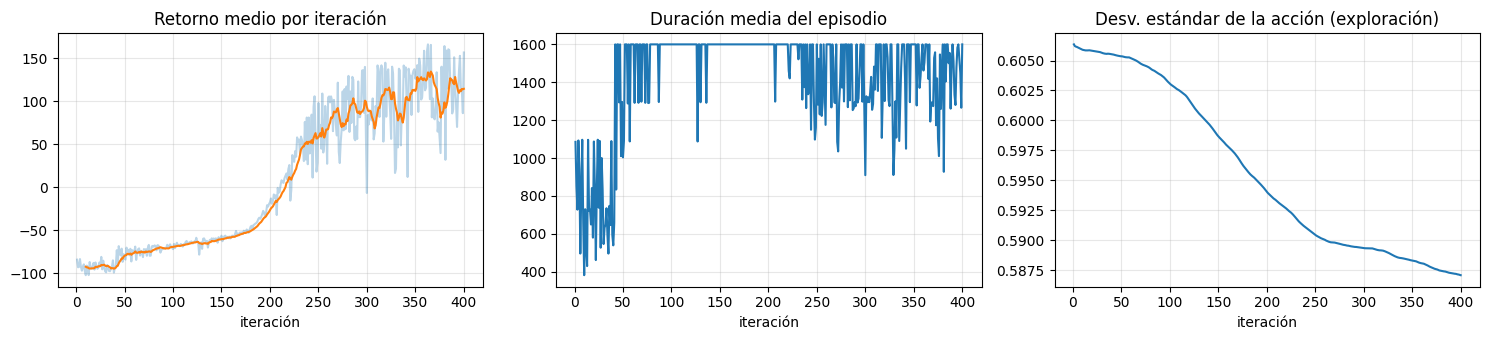

In [ ]:
plot_progress(trainer)

## 7. Galería de la evolución 🎞️
Los videos guardados en orden: del robot recién nacido al robot entrenado.

In [ ]:
MAX_VIDEOS = 8
vids = trainer.videos
idx = np.unique(np.linspace(0, len(vids) - 1, min(MAX_VIDEOS, len(vids))).astype(int))
show_videos([(f"it {vids[i][0]} — retorno {vids[i][1]:.0f}", vids[i][2]) for i in idx], width=300)

## 8. Medición final de la distancia 📏
El agente corre 20 episodios en terrenos fijos, sin ruido aleatorio en sus acciones.

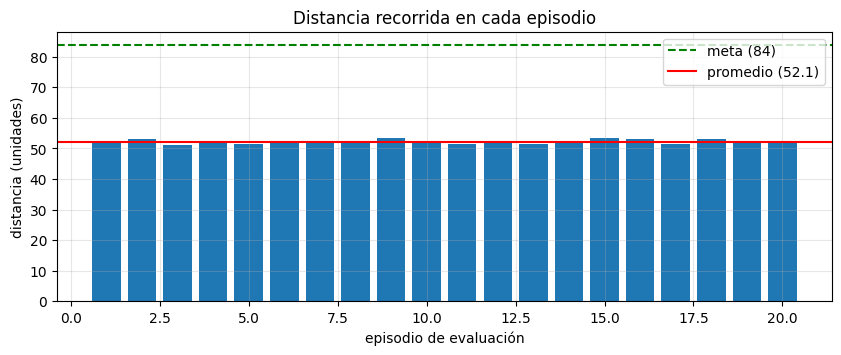

In [ ]:
distancias = [distancia_episodio(trainer, s) for s in EVAL_SEEDS]
dist_media, dist_max = float(np.mean(distancias)), float(np.max(distancias))

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.bar(range(1, len(distancias) + 1), distancias)
ax.axhline(DISTANCIA_META, color="green", ls="--", label=f"meta ({DISTANCIA_META:.0f})")
ax.axhline(dist_media, color="red", ls="-", label=f"promedio ({dist_media:.1f})")
ax.set_xlabel("episodio de evaluación"); ax.set_ylabel("distancia (unidades)")
ax.set_title("Distancia recorrida en cada episodio"); ax.legend(); ax.grid(alpha=0.3)
plt.show()

mejor_seed = EVAL_SEEDS[int(np.argmax(distancias))]
ruta = "videos/mejor_episodio_final.mp4"
distancia_episodio(trainer, mejor_seed, video_path=ruta)
show_videos([(f"Mejor episodio de la evaluación — {dist_max:.1f} unidades", ruta)], width=480)

## 9. Resultado para reportar 🏆

In [ ]:
print("=" * 52)
print("          RESULTADO PARA REPORTAR")
print("=" * 52)
print(f"Estudiante            : {NOMBRE_ESTUDIANTE or '(sin nombre)'}")
print(f"Iteraciones entrenadas: {trainer.it}")
print(f"Hiperparámetros       : N_ITERS={N_ITERS}, BATCH_STEPS={BATCH_STEPS}, LR_POLICY={LR_POLICY},")
print(f"                        LR_VALUE={LR_VALUE}, GAMMA={GAMMA}, ENT_COEF={ENT_COEF},")
print(f"                        HIDDEN={HIDDEN}, SEED={SEED}")
print("-" * 52)
print(f"Distancia máxima      : {dist_max:.1f} unidades")
print(f"DISTANCIA MEDIA       : {dist_media:.1f} unidades  ({100 * dist_media / DISTANCIA_META:.0f}% del circuito)")
print("=" * 52)
print("Reporta la DISTANCIA MEDIA junto con tus hiperparámetros.")

          RESULTADO PARA REPORTAR
Estudiante            : (sin nombre)
Iteraciones entrenadas: 400
Hiperparámetros       : N_ITERS=400, BATCH_STEPS=5000, LR_POLICY=0.0003,
                        LR_VALUE=0.001, GAMMA=0.99, ENT_COEF=0.0,
                        HIDDEN=128, SEED=0
----------------------------------------------------
Distancia máxima      : 53.5 unidades
DISTANCIA MEDIA       : 52.1 unidades  (62% del circuito)
Reporta la DISTANCIA MEDIA junto con tus hiperparámetros.


## Consejos
- REINFORCE tiene mucha varianza: dos entrenamientos con los mismos hiperparámetros pueden dar resultados distintos si se cambia `SEED`.
- Si el robot se queda quieto, es normal en las primeras iteraciones, es decir, quedarse quieto evita caerse y perder puntos. Se le puede dar tiempo o aumentar `BATCH_STEPS`.
- Más iteraciones y más pasos por iteración suelen ayudar, pero aumentan el tiempo de ejecución.
- Si el aprendizaje es inestable (la curva sube y baja mucho), probar con una tasa de aprendizaje mas reducida.
- Observar los videos, en ellos se observa qué estrategia está aprendiendo el robot (arrastrarse, dar pasos cortos, saltar...).